# 05 — GATU vs ViraLift: 50-record head-to-head (PRRSV)

Scale-up of `gatu_5case_validate.ipynb`. **Same reference (`PQ623173.1`), same metric, same code
path** — only the record set changes, so the two runs are directly comparable and the 5 pilot
records are held out (no overlap).

**Selection.** 50 records drawn with `random.Random(20260816).sample(...)` from
`PRRS_100seq_anno.gb`, restricted to records whose truth annotation covers **>= 8 of the 9
reference genes** (the profile of the pilot 5) and excluding the pilot accessions.
Eligible pool: 75. Result: 40 records with 8 genes, 10 with 9 → **410 truth genes**.
The pick is listed in `picks.txt`; re-running `build_50case.py` with the same seed reproduces it.

**Scoring.** Truth-anchored, coordinate-only (IoU >= 0.90 or +-6 bp, codon check OFF for both
tools), denominator = reference genes present in truth (R ∩ truth). Identical to the 5-case
notebook and `../VALIDATION_METHODOLOGY.md`.

### Run order
1. **GATU** (manual, one genome at a time): load reference `reference_PQ623173.gb` + each
   `targets/<acc>.fasta`, accept the transferred annotations, save as GenBank to
   `gatu_output/<acc>.gb`. Track progress in `gatu_run_checklist.csv` (tick the `done` column).
2. **Run this notebook** (needs `tblastn` on PATH). It lifts all 50 targets with ViraLift,
   ingests whatever GATU outputs are present, and scores both. Partial GATU coverage is fine —
   the notebook reports how many records it scored and pairs the two tools on those records only.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd, matplotlib.pyplot as plt
from Bio import SeqIO
from app.validation._shared.validation_utils import *
from app.src.lifting.tblastn_lifter import lift_all_tblastn
from app.src.alias.gene_alias import apply_alias_to_features
from app.src.pipeline import PipelineConfig

CASE = Path('outputs/gatu_50case')
PICK = (CASE / 'picks.txt').read_text().split()
REF  = CASE / 'reference_PQ623173.gb'
bundle = load_reference_bundle(REF)
CFG = PipelineConfig()   # production defaults, same as the accuracy harness
ref_names = sorted({f['name'] for f in bundle['features']})  # evaluable set R

truth_src = {r.id: r for r in load_genbank_records(DATA/'PRRS'/'PRRS_100seq_anno.gb') if r.id in PICK}
target_records = {p.stem: SeqIO.read(str(p),'fasta') for p in (CASE/'targets').glob('*.fasta')}
for acc in PICK:
    assert str(target_records[acc].seq) == str(truth_src[acc].seq), f'seq mismatch {acc}'
print('reference:', bundle['record'].id, '| R =', ref_names)
print('targets:', len(PICK), 'records')

reference: PQ623173.1 | R = ['ORF1a', 'ORF1b', 'ORF2a', 'ORF2b', 'ORF3', 'ORF4', 'ORF5', 'ORF6', 'ORF7']
targets: 50 records


In [2]:
# Truth per record: R n truth (reference genes only), same as the accuracy harness
# dedupe_truth_by_name: one truth feature per name, matching how the comparator resolves
# truth (longest wins) and how the accuracy harness counts (record, gene) presence.
truth_by_acc = {acc: dedupe_truth_by_name(
                    parse_truth_features(truth_src[acc], bundle['alias_lookup'], bundle['feature_type'],
                                         filter_nested=False, target_names=ref_names, keep_extra_names=[])[0])
                for acc in PICK}
print('truth genes total:', sum(len(v) for v in truth_by_acc.values()))

def coverage_rows(tool, acc, preds):
    """Truth-anchored, coordinate-only (codon OFF for both tools)."""
    truth = truth_by_acc[acc]
    if preds:
        cmp = compare_predictions_to_truth(preds, truth, codon_required_names=set())
        correct = set(cmp.loc[cmp['coord_correct'], 'pred_name']) if 'coord_correct' in cmp.columns else set()
        exact   = set(cmp.loc[cmp['exact_match'], 'pred_name']) if 'exact_match' in cmp.columns else set()
    else:
        correct, exact = set(), set()
    # 'exact' mirrors the accuracy harness's exact / coord_only split (02_lifting_accuracy),
    # so the two units report the same three buckets on the same lift.
    return [{'tool': tool, 'accession': acc, 'gene': t['name'],
             'found': t['name'] in correct, 'exact': t['name'] in exact} for t in truth]

truth genes total: 410


In [3]:
# ---- ViraLift (tblastn lift onto the SAME stripped target FASTA) ----
cov = []
viralift_lifts = {}
for i, acc in enumerate(PICK, 1):
    # Same call shape as the accuracy harness (validation_utils.run_tblastn_against_truth):
    # production config is passed explicitly, never left to the function signature's
    # incidental defaults, so a change to PipelineConfig propagates here too.
    lifted = lift_all_tblastn(
        ref_features=bundle['features'], ref_record=bundle['record'],
        query_record=target_records[acc],
        min_coverage=CFG.min_coverage, min_identity=CFG.min_identity,
        evalue=CFG.evalue, rescue_window=CFG.rescue_window,
        validate_codons=(bundle['feature_type']=='CDS'))
    viralift_lifts[acc] = lifted
    cov += coverage_rows('ViraLift', acc, lifted_to_rows(acc, lifted, 'viralift'))
    if i % 10 == 0: print(f'  {i}/{len(PICK)} lifted')
print('ViraLift done:', sum(r['found'] for r in cov), '/', len(cov))

  10/50 lifted


  20/50 lifted


  30/50 lifted


  40/50 lifted


  50/50 lifted
ViraLift done: 410 / 410


In [4]:
# ---- GATU ingest (from outputs/gatu_50case/gatu_output/<acc>.gb) ----
def load_gatu_preds(acc):
    # GATU may drop the 2-letter accession prefix (AF184212.1 -> 184212.1);
    # match on filename suffix rather than exact prefix.
    hits = []
    for ext in ('gb','gbk','genbank','gbf'):
        hits += [p for p in (CASE/'gatu_output').glob(f'*.{ext}')
                 if acc.endswith(p.stem) or p.stem.endswith(acc)]
    if not hits:
        return None
    rec = load_single_genbank(hits[0])
    feats = parse_features_for_type(rec, 'CDS')
    if not feats:
        return []
    feats = apply_alias_to_features(feats, bundle['alias_lookup'])  # normalise names like truth
    return [{'record_id':acc,'method':'gatu','pred_name':f['name'],
             'pred_start':f['start'],'pred_end':f['end'],'strand':f['strand'],
             'has_start_codon':None,'has_stop_codon':None,'in_frame':None} for f in feats]

gatu_done, missing = [], []
for acc in PICK:
    preds = load_gatu_preds(acc)
    if preds is None:
        missing.append(acc); continue
    gatu_done.append(acc)
    cov += coverage_rows('GATU', acc, preds)

print(f'GATU outputs present: {len(gatu_done)}/{len(PICK)}')
if missing:
    print('still missing:', ', '.join(missing))
    print('-> run GATU, save to outputs/gatu_50case/gatu_output/<acc>.gb, then re-run.')
cov_df = pd.DataFrame(cov)
cov_df.to_csv(CASE/'coverage_per_gene.tsv', sep='\t', index=False)
cov_df.head()

GATU outputs present: 50/50


/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AB811786  15313 bp    DNA    VRL 18-Aug- 202\n'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AB811788  15308 bp    DNA    VRL 18-Aug- 202\n'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AF494042  15450 bp    DNA    VRL 18-Aug- 202\n'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AY150564  15451 bp    DNA    VRL 18-Aug- 202\n'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is thi

,tool,accession,gene,found,exact
0,ViraLift,AB811785.1,ORF1a,True,True
1,ViraLift,AB811785.1,ORF1b,True,False
2,ViraLift,AB811785.1,ORF2a,True,True
3,ViraLift,AB811785.1,ORF3,True,True
4,ViraLift,AB811785.1,ORF4,True,True


In [5]:
# ---- Summary (truth-anchored). Restricted to records BOTH tools covered, for fairness. ----
paired = cov_df[cov_df['accession'].isin(gatu_done)] if gatu_done else cov_df
summary = (paired.groupby('tool').agg(truth_genes=('found','size'), correct=('found','sum')).reset_index())
summary['coord_pct'] = (summary['correct']/summary['truth_genes']*100).round(2)
summary['n_records'] = paired.groupby('tool')['accession'].nunique().values
summary.to_csv(CASE/'summary_50case.tsv', sep='\t', index=False)
print(f'paired on {len(gatu_done)} records')
print(summary.to_string(index=False))

# ORF5 line (primer-design target)
o = paired[paired['gene']=='ORF5']
print('\nORF5:', o.groupby('tool')['found'].agg(['sum','size']).to_dict('index'))

paired on 50 records
    tool  truth_genes  correct  coord_pct  n_records
    GATU          410      361      88.05         50
ViraLift          410      410     100.00         50

ORF5: {'GATU': {'sum': 50, 'size': 50}, 'ViraLift': {'sum': 50, 'size': 50}}


In [6]:
# ---- exact / coord-only / failed, same buckets as 02_lifting_accuracy ----
buckets = (paired.assign(
        bucket=lambda d: d.apply(
            lambda r: 'exact' if r['exact'] else ('coord_only' if r['found'] else 'failed'), axis=1))
    .pivot_table(index='tool', columns='bucket', values='gene', aggfunc='size', fill_value=0))
buckets = buckets.reindex(columns=['exact','coord_only','failed'], fill_value=0)
buckets['total'] = buckets.sum(axis=1)
buckets['accuracy_pct'] = ((buckets['exact']+buckets['coord_only'])/buckets['total']*100).round(2)
buckets.to_csv(CASE/'buckets_50case.tsv', sep='\t')
print(buckets.to_string())

# per-gene exact rate — ORF1b's 0 exact is the frameshift-convention signature
ex = (paired.groupby(['gene','tool'])['exact'].mean().mul(100).round(1)
      .unstack('tool').reindex([g for g in ref_names if g in set(paired['gene'])]))
ex.to_csv(CASE/'exact_per_gene.tsv', sep='\t')
print('\nexact-match % per gene:'); print(ex.to_string())

bucket    exact  coord_only  failed  total  accuracy_pct
tool                                                    
GATU        354           7      49    410         88.05
ViraLift    359          51       0    410        100.00

exact-match % per gene:
tool    GATU  ViraLift
gene                  
ORF1a   89.5      97.4
ORF1b    0.0       0.0
ORF2a  100.0     100.0
ORF2b  100.0     100.0
ORF3   100.0     100.0
ORF4   100.0     100.0
ORF5   100.0     100.0
ORF6   100.0     100.0
ORF7    96.0     100.0


In [7]:
# ---- Side-by-side per (accession, gene) + per-gene table ----
side = paired.pivot_table(index=['accession','gene'], columns='tool', values='found', aggfunc='first')
side.to_csv(CASE/'side_by_side.tsv', sep='\t')

per_gene = (paired.groupby(['gene','tool']).agg(n=('found','size'), correct=('found','sum')).reset_index())
per_gene['pct'] = (per_gene['correct']/per_gene['n']*100).round(1)
per_gene = per_gene.pivot_table(index='gene', columns='tool', values='pct', fill_value=0)
per_gene = per_gene.reindex([g for g in ref_names if g in per_gene.index])
per_gene.to_csv(CASE/'per_gene.tsv', sep='\t')

# records where the two tools disagree — the interesting cases for the paper
if 'GATU' in side.columns:
    disagree = side[side['GATU'] != side['ViraLift']].reset_index()
    disagree.to_csv(CASE/'disagreements.tsv', sep='\t', index=False)
    print(f'{len(disagree)} (record, gene) disagreements -> disagreements.tsv')
per_gene

49 (record, gene) disagreements -> disagreements.tsv


tool,GATU,ViraLift
gene,,
ORF1a,92.1,100.0
ORF1b,12.0,100.0
ORF2a,100.0,100.0
ORF2b,100.0,100.0
ORF3,100.0,100.0
ORF4,100.0,100.0
ORF5,100.0,100.0
ORF6,100.0,100.0
ORF7,96.0,100.0


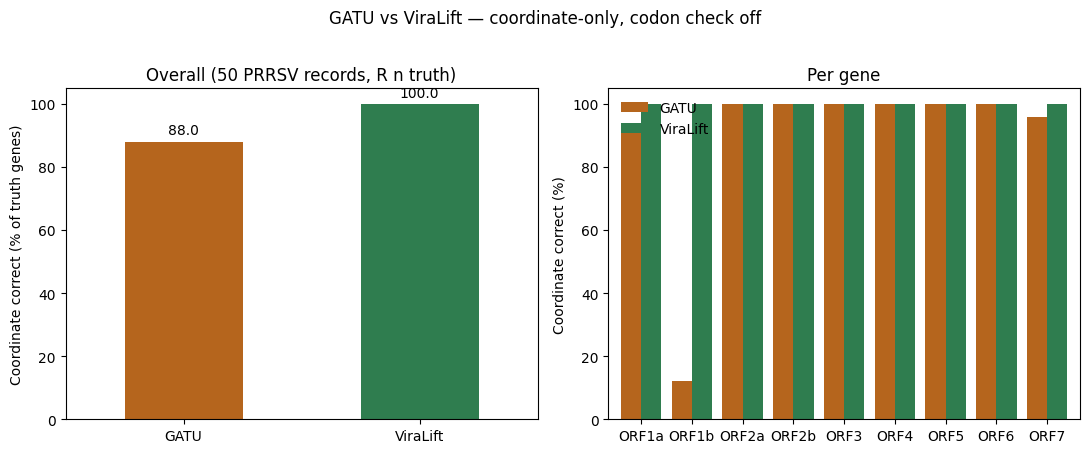

In [8]:
# ---- Figure ----
if 'GATU' in set(paired['tool']):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    summary.set_index('tool')['coord_pct'].reindex(['GATU','ViraLift']).plot(
        kind='bar', ax=axes[0], color=['#b5651d','#2f7d4f'], rot=0)
    axes[0].set_ylim(0,105); axes[0].set_ylabel('Coordinate correct (% of truth genes)'); axes[0].set_xlabel('')
    axes[0].set_title(f'Overall ({len(gatu_done)} PRRSV records, R n truth)')
    for c in axes[0].containers: axes[0].bar_label(c, fmt='%.1f', padding=3)

    per_gene.reindex(columns=['GATU','ViraLift']).plot(
        kind='bar', ax=axes[1], color=['#b5651d','#2f7d4f'], rot=0, width=0.8)
    axes[1].set_ylim(0,105); axes[1].set_ylabel('Coordinate correct (%)'); axes[1].set_xlabel('')
    axes[1].set_title('Per gene'); axes[1].legend(frameon=False)
    fig.suptitle('GATU vs ViraLift — coordinate-only, codon check off', y=1.02)
    fig.tight_layout(); fig.savefig(CASE/'gatu_vs_viralift_50.png', dpi=180, bbox_inches='tight')
else:
    print('Add GATU outputs to draw the comparison figure.')

In [9]:
# ---- Per-gene IoU matrix: rows = (record x tool), cols = reference genes ----
# Each cell = IoU of that tool's lifted gene vs truth (1.0 = identical span).
#   blank = gene not annotated in that record's truth;  0.0 = not lifted / wrong region.
def iou_by_gene(acc, preds):
    truth = truth_by_acc[acc]
    if preds:
        cmp = compare_predictions_to_truth(preds, truth, codon_required_names=set())
        iou_map = dict(zip(cmp['pred_name'], cmp['iou'].round(3))) if 'iou' in cmp.columns else {}
    else:
        iou_map = {}
    return {t['name']: iou_map.get(t['name'], 0.0) for t in truth}

iou_long = []
for acc in PICK:
    # reuse the lifts computed above — no second tblastn pass
    iou_long.append({'accession': acc, 'tool': 'ViraLift',
                     **iou_by_gene(acc, lifted_to_rows(acc, viralift_lifts[acc], 'viralift'))})
    if acc in gatu_done:
        iou_long.append({'accession': acc, 'tool': 'GATU',
                         **iou_by_gene(acc, load_gatu_preds(acc) or [])})

iou_mat = pd.DataFrame(iou_long).set_index(['accession', 'tool']).sort_index()
iou_mat = iou_mat.reindex(columns=[g for g in ref_names if g in iou_mat.columns])
iou_mat.to_csv(CASE / 'iou_matrix.tsv', sep='\t')
print('IoU per (record x tool) x gene  --  green=good lift, red=off, blank=not in truth')
iou_mat.style.background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=None).format('{:.2f}', na_rep='')

/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AB811786  15313 bp    DNA    VRL 18-Aug- 202\n'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AB811788  15308 bp    DNA    VRL 18-Aug- 202\n'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AF494042  15450 bp    DNA    VRL 18-Aug- 202\n'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AY150564  15451 bp    DNA    VRL 18-Aug- 202\n'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1574: BiopythonParserWarning: Malformed LOCUS line found - is thi

IoU per (record x tool) x gene  --  green=good lift, red=off, blank=not in truth


In [10]:
# ---- Pilot (5) + scale-up (50) combined view, for the paper ----
p5 = Path('outputs/gatu_5case/coverage_per_gene.tsv')
if p5.exists() and gatu_done:
    prev = pd.read_csv(p5, sep='\t'); prev['set'] = 'pilot (5)'
    cur  = paired.copy(); cur['set'] = f'scale-up ({len(gatu_done)})'
    both = pd.concat([prev, cur], ignore_index=True)
    combo = (both.groupby(['set','tool']).agg(truth_genes=('found','size'), correct=('found','sum')).reset_index())
    combo['coord_pct'] = (combo['correct']/combo['truth_genes']*100).round(2)
    combo.to_csv(CASE/'summary_pilot_plus_scaleup.tsv', sep='\t', index=False)
    print(combo.to_string(index=False))
else:
    print('Pilot coverage table or GATU outputs not available yet.')

          set     tool  truth_genes  correct  coord_pct
    pilot (5)     GATU           42       37      88.10
    pilot (5) ViraLift           42       42     100.00
scale-up (50)     GATU          410      361      88.05
scale-up (50) ViraLift          410      410     100.00
